<a href="https://colab.research.google.com/github/1G4S/mechanical-processing/blob/main/SystemWczesnegoOstrzegania.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [2]:
def build_anomaly_detection_system(filepath='dane_obrobka_cnc.csv'):
    print("--- ETAP 4: BUDOWA SYSTEMU WCZESNEGO OSTRZEGANIA ---")
    df = pd.read_csv(filepath)

    # 1. WYBÓR CECH DO DETEKCJI (Tylko dane sensoryczne z maszyny)
    # Ignorujemy parametry zadane (jak posuw) i skupiamy się na tym, co maszyna "czuje"
    sensor_features = [
        'Wibracje_Wrzeciona_RMS_g',
        'Pobor_Mocy_Mean_kW',
        'Temp_Narzedzia_Max_C',
        'Temp_Chlodziwa_Mean_C',
        'Cisnienie_Chlodziwa_Min_bar'
    ]

    # Zastąpienie błędów czujnika (jeśli jeszcze są) na potrzeby Isolation Forest
    # Uzupełniamy medianą, aby las mógł działać na liczbach
    X_sensors = df[sensor_features].copy()
    X_sensors.fillna(X_sensors.median(), inplace=True)

    # 2. TRENING MODELU ISOLATION FOREST
    print("Trenowanie modelu Isolation Forest...")
    # contamination=0.01 oznacza, że zakładamy z góry, iż ok. 1% danych na produkcji to anomalie
    iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

    # Model zwraca -1 dla anomalii i 1 dla danych normalnych
    anomaly_labels = iso_forest.fit_predict(X_sensors)

    # Mapujemy wyniki: 1 to anomalia, 0 to norma (wygodniejsze dla Power BI)
    df['Anomalia_Systemowa'] = np.where(anomaly_labels == -1, 1, 0)

    anomalies_count = df['Anomalia_Systemowa'].sum()
    print(f"Zakończono! Wykryto {anomalies_count} anomalii w zbiorze {len(df)} rekordów.")

    # 3. WIZUALIZACJA WYNIKÓW
    print("Generowanie wizualizacji...")
    plt.figure(figsize=(10, 6))

    # Scatter plot: Pobór Mocy vs Wibracje
    sns.scatterplot(
        data=df,
        x='Pobor_Mocy_Mean_kW',
        y='Wibracje_Wrzeciona_RMS_g',
        hue='Anomalia_Systemowa',
        palette={0: 'steelblue', 1: 'crimson'},
        alpha=0.6,
        s=40
    )

    plt.title('Detekcja Anomalii Procesowych - Isolation Forest', fontsize=15, pad=15)
    plt.xlabel('Średni Pobór Mocy [kW]', fontweight='bold')
    plt.ylabel('Wibracje Wrzeciona RMS [g]', fontweight='bold')

    # Dostosowanie legendy
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['Norma (0)', 'Anomalia (1)'], title='Status', loc='upper left')

    plt.tight_layout()
    plt.savefig('detekcja_anomalii.png', bbox_inches='tight')
    plt.show()

    # 4. ZAPIS DO POWER BI
    df.to_csv(filepath, index=False)
    print(f"Zaktualizowano plik '{filepath}' o kolumnę 'Anomalia_Systemowa' pod Power BI.")


--- ETAP 4: BUDOWA SYSTEMU WCZESNEGO OSTRZEGANIA ---
Trenowanie modelu Isolation Forest...
Zakończono! Wykryto 300 anomalii w zbiorze 30000 rekordów.
Generowanie wizualizacji...


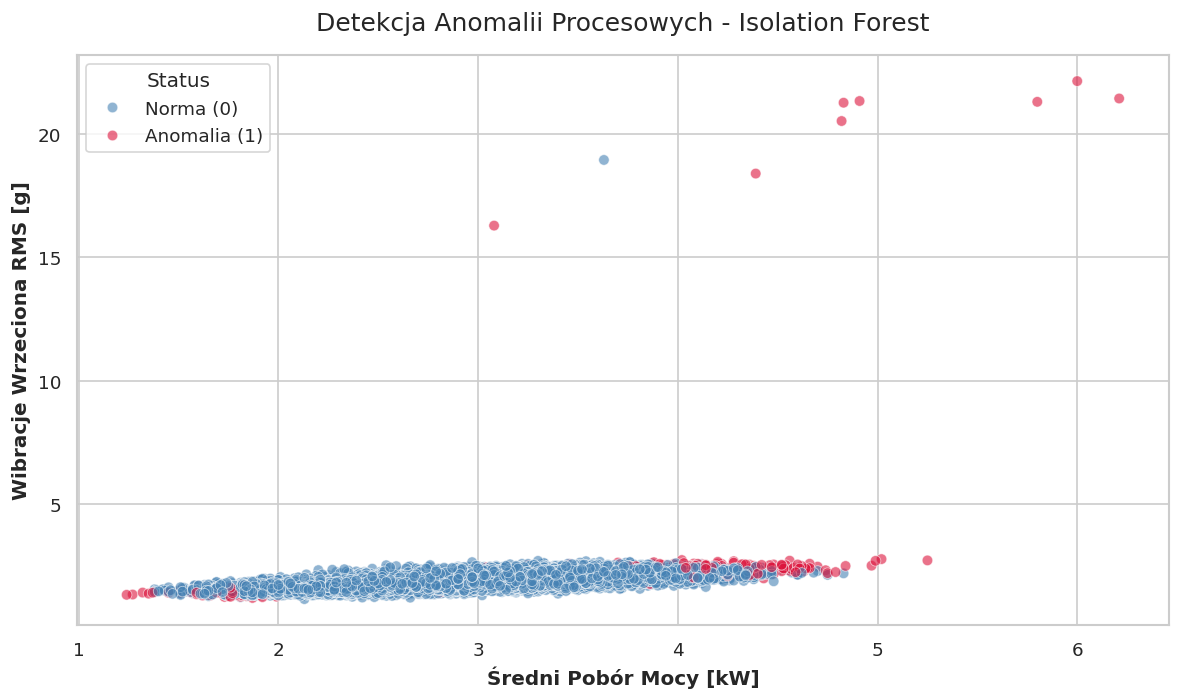

Zaktualizowano plik 'dane_obrobka_cnc.csv' o kolumnę 'Anomalia_Systemowa' pod Power BI.


In [4]:
# Uruchomienie
build_anomaly_detection_system()

Wyniki działania algorytmu Isolation Forest w dwuwymiarowej przestrzeni cech (pobór mocy vs. wibracje). Czerwonym kolorem zaznaczono rekordy sklasyfikowane jako anomalie systemowe, wymagające natychmiastowego przerwania pracy maszyny.

Aby w pełni zrealizować założenia koncepcji Przemysłu 4.0, oprócz predykcji jakościowej, zaprojektowano moduł wczesnego ostrzegania oparty na uczeniu nienadzorowanym (ang. Unsupervised Learning). Wykorzystano w tym celu algorytm Isolation Forest (Las Izolacji), którego zadaniem jest detekcja wartości odstających w czasie rzeczywistym, wyłącznie na podstawie strumienia danych z czujników (wibracje, pobór mocy, temperatury).

Jak zilustrowano na Rysunku, algorytm skutecznie odizolował stany nienormalne maszyny. Odseparowane przypadki (zaznaczone na czerwono) korelują w zbiorze danych z symulowanymi pęknięciami narzędzia oraz skrajnym jego zużyciem, przy których następował nienaturalny skok wibracji i oporów skrawania. Wdrożenie takiego mikro-modelu na urządzeniach brzegowych (ang. Edge Devices) bezpośrednio przy sterowniku CNC pozwala na sprzętowe zatrzymanie wrzeciona w ułamku sekundy, zapobiegając zniszczeniu detalu oraz chroniąc kinematykę obrabiarki przed poważną awarią. Ponadto oflagowane anomalie są wykluczane z wnioskowania przez główny model regresyjny, co znacząco zwiększa jego stabilność na linii produkcyjnej.

Analizując wizualizację wyników detekcji anomalii (Rysunek W), można dostrzec pewne pozornie nielogiczne klasyfikacje – np. obecność punktów oznaczonych jako anomalia (czerwonych) w głównym skupisku danych poprawnych, czy pojedynczych punktów uznanych za normę przy wysokich wartościach wibracji. Zjawisko to jest jednak potwierdzeniem prawidłowego działania algorytmu w wielowymiarowej przestrzeni cech.

Wykres stanowi jedynie rzut 2D z 5-wymiarowej hiperprzestrzeni (obejmującej dodatkowo ciśnienie i temperatury). Punkty uznane za anomalię w głównym klastrze reprezentują detale o prawidłowych parametrach mechanicznych, ale drastycznych odchyleniach w układzie chłodzenia (np. zator cieczy, spadek ciśnienia), co Isolation Forest poprawnie zidentyfikował jako stany awaryjne. Z kolei niezakwalifikowanie skrajnego punktu o wysokich wibracjach do grupy anomalii wynika z zastosowanego, restrykcyjnego progu odcięcia (contamination = 0.01), limitującego liczbę wykrywanych alertów do 1% najbardziej ekstremalnych przypadków we wszystkich pięciu wymiarach jednocześnie.